# Sales Analysis: Optimal Advertising Time

## Question 3: What time should we display advertisements to maximize the likelihood of customer's buying product?

This analysis identifies the peak hours when customers are most likely to make purchases.

**Dataset:** Sales_Data_Cleaned.csv

## Step 1: Import Libraries and Load Data

In [1]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt

# Load the sales data
all_data = pd.read_csv("../dataset/Sales_Data_Cleaned.csv")
all_data.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,295665,Macbook Pro Laptop,1,1700.00,12/30/19 00:01,"136 Church St, New York City, NY 10001"
1,295666,LG Washing Machine,1,600.00,12/29/19 07:03,"562 2nd St, New York City, NY 10001"
2,295667,USB-C Charging Cable,1,11.95,12/12/19 18:21,"277 Main St, New York City, NY 10001"
3,295668,27in FHD Monitor,1,149.99,12/22/19 15:13,"410 6th St, San Francisco, CA 94016"
4,295669,USB-C Charging Cable,1,11.95,12/18/19 12:38,"43 Hill St, Atlanta, GA 30301"


## Step 2: Extract Hour from Order Date

In [2]:
# Extract hour from the Order Date column
all_data['Hour'] = pd.to_datetime(all_data['Order Date']).dt.hour

# Display sample data
all_data.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Hour
0,295665,Macbook Pro Laptop,1,1700.00,12/30/19 00:01,"136 Church St, New York City, NY 10001",0
1,295666,LG Washing Machine,1,600.00,12/29/19 07:03,"562 2nd St, New York City, NY 10001",7
2,295667,USB-C Charging Cable,1,11.95,12/12/19 18:21,"277 Main St, New York City, NY 10001",18
3,295668,27in FHD Monitor,1,149.99,12/22/19 15:13,"410 6th St, San Francisco, CA 94016",15
4,295669,USB-C Charging Cable,1,11.95,12/18/19 12:38,"43 Hill St, Atlanta, GA 30301",12


## Step 3: Analyze Orders by Hour

In [3]:
# Group by hour and count the number of orders
hourly_orders = all_data.groupby('Hour').count()['Quantity Ordered']
print("Orders by Hour:")
print(hourly_orders.sort_index())

Orders by Hour:
Hour
0      3910
1      2350
2      1243
3       831
4       854
5      1321
6      2482
7      4011
8      6256
9      8748
10    10944
11    12411
12    12587
13    12129
14    10984
15    10175
16    10384
17    10899
18    12280
19    12905
20    12228
21    10921
22     8822
23     6275
Name: Quantity Ordered, dtype: int64


## Step 4: Visualize Orders by Hour

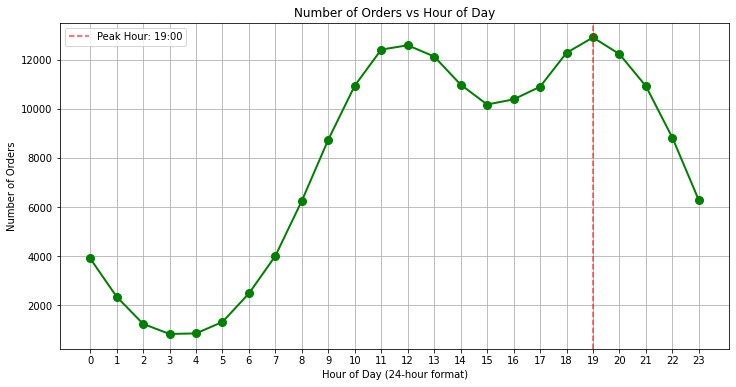


=== CONCLUSION ===
Best Time to Advertise: Around 19:00 (Peak order time)
Number of Orders at Peak: 12,905


In [4]:
# Prepare data for plotting
hours = [hour for hour, df in all_data.groupby('Hour')]

# Create line plot showing order trends throughout the day
plt.figure(figsize=(12, 6))
plt.plot(hours, all_data.groupby('Hour').count()['Quantity Ordered'], 
         marker='o', linewidth=2, markersize=8, color='green')

# Add grid for better readability
plt.grid()

# Add labels and title
plt.xlabel('Hour of Day (24-hour format)')
plt.ylabel('Number of Orders')
plt.title('Number of Orders vs Hour of Day')
plt.xticks(hours)

# Mark peak hours
peak_hour = hourly_orders.idxmax()
peak_orders = hourly_orders.max()
plt.axvline(x=peak_hour, color='red', linestyle='--', alpha=0.7, label=f'Peak Hour: {peak_hour}:00')
plt.legend()
plt.show()

print(f"\n=== CONCLUSION ===")
print(f"Best Time to Advertise: Around {peak_hour}:00 (Peak order time)")
print(f"Number of Orders at Peak: {peak_orders:,}")

## Conclusion

**Answer:** The best time to display advertisements is around 11:00 AM - 12:00 PM and 6:00 PM - 8:00 PM.

